# 전처리 4단계 — 파생변수: 일 가중치 w_d v2 (6개년 확장)

## w_d란?

> 산불은 특정 계절에 집중됩니다. 강원도는 **3월 말~4월 초**가 가장 위험합니다.  
> w_d는 "지금이 얼마나 산불이 나기 쉬운 계절인가"를 0.33~1.0으로 표현하는 계절 가중치입니다.
>
> **DWI 공식에서의 역할**:  
> `DWI = PreDWI_등급 × RNE × w_d`  
> 또는 최종 FFDRI 산출식에서 일 가중치로 적용됩니다.

## 출처
산림청 FFDRI(산불위험지수) 알고리즘 설명서 (2026.04.20)

## v1 대비 변경점

| 항목 | v1 | v2 |
|-|---|---|
| 처리 기간 | 2025년 2~5월 | **2020~2025년 2~5월** |
| 결과 크기 | 120행 | **721행** (2020년 윤년 포함) |
| 계산 방식 | 날짜별 w_d 생성 | 동일 |
| 시각화 | 2025년 기준 | 2020~2025 분석기간 + 연간 패턴 |

→ w_d는 격자별로 달라지지 않으므로, 6개년으로 확장해도 날짜 테이블만 만들면 됩니다.

In [32]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 0. 프로젝트 루트 / 저장 경로 설정
# ============================================================

def find_project_root(start=None):
    """
    노트북 실행 위치가 달라도 프로젝트 루트를 찾기 위한 함수.
    우선순위:
    1) .project-root 파일이 있는 위치
    2) preprocessing 폴더가 있는 위치
    3) 현재 작업 디렉터리
    """
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / '.project-root').exists():
            return path

    for path in [start, *start.parents]:
        if (path / 'preprocessing').exists():
            return path

    return start

PROJECT_ROOT = find_project_root()

# 기존 코드 흐름을 유지하되, 경로는 프로젝트 루트 기준으로 정리
BASE_PATH   = PROJECT_ROOT / 'preprocessing'
OUTPUT_PATH = BASE_PATH / 'derived'
FIG_PATH    = BASE_PATH / 'PREP04'

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIG_PATH.mkdir(parents=True, exist_ok=True)

print('설정 완료')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'BASE_PATH   : {BASE_PATH}')
print(f'OUTPUT_PATH : {OUTPUT_PATH}')
print(f'FIG_PATH    : {FIG_PATH}')

설정 완료
PROJECT_ROOT: C:\SKN projects\weather
BASE_PATH   : C:\SKN projects\weather\preprocessing
OUTPUT_PATH : C:\SKN projects\weather\preprocessing\derived
FIG_PATH    : C:\SKN projects\weather\preprocessing\PREP04


---
## Step 1. w_d 기준표 정의

> 산림청 FFDRI 기준. 3월 하순~4월 상순(1.0)이 연중 최고 위험 시기입니다.

본 프로젝트에서는 현재 기상 데이터 기간에 맞춰 **2020~2025년 2~5월** 날짜 테이블을 생성합니다.

In [33]:
# 월/일 → w_d 반환 함수 (출처: 산림청 FFDRI)
def get_wd(month, day):
    if month == 1:            return 0.85
    if month == 2:            return 0.85
    if month == 3:
        if day <= 10:         return 0.90
        if day <= 20:         return 0.95
        return 1.00
    if month == 4:
        if day <= 10:         return 1.00
        if day <= 20:         return 0.95
        return 0.90
    if month == 5:            return 0.85
    if month == 6:            return 0.80
    if month == 7:            return 0.33
    if month == 8:            return 0.33
    if month == 9:            return 0.50
    if month == 10:           return 0.61
    if month == 11:           return 0.78
    if month == 12:           return 0.83
    return 1.0

# ============================================================
# 데이터 기간 날짜 테이블 생성: 2020~2025년 2~5월
# ============================================================
YEARS = range(2020, 2026)
TARGET_MONTHS = [2, 3, 4, 5]

date_list = []
for y in YEARS:
    for m in TARGET_MONTHS:
        start = pd.Timestamp(f'{y}-{m:02d}-01')
        end = start + pd.offsets.MonthEnd(0)
        date_list.extend(pd.date_range(start, end))

wd_df = pd.DataFrame({'date': date_list})
wd_df['date']  = pd.to_datetime(wd_df['date'])
wd_df['year']  = wd_df['date'].dt.year
wd_df['month'] = wd_df['date'].dt.month
wd_df['day']   = wd_df['date'].dt.day
wd_df['ym']    = wd_df['date'].dt.strftime('%Y-%m')
wd_df['w_d']   = wd_df.apply(lambda r: get_wd(r['month'], r['day']), axis=1).astype('float32')

print(f'총 {len(wd_df)}일치 w_d 생성')
print(f'기간: {wd_df["date"].min().date()} ~ {wd_df["date"].max().date()}')
print(f'연도: {wd_df["year"].min()} ~ {wd_df["year"].max()}')
print()

print('=== 연도별 날짜 수 ===')
print(wd_df.groupby('year').size().to_string())
print()

print('=== 구간별 w_d 요약 ===')
for wd_val in sorted(wd_df['w_d'].unique(), reverse=True):
    risk = '최고' if wd_val == 1.0 else '높음' if wd_val >= 0.9 else '중간' if wd_val >= 0.8 else '낮음'
    print(f'  w_d={wd_val:.2f}  {(wd_df["w_d"] == wd_val).sum():4d}일  [{risk}]')

총 722일치 w_d 생성
기간: 2020-02-01 ~ 2025-05-31
연도: 2020 ~ 2025

=== 연도별 날짜 수 ===
year
2020    121
2021    120
2022    120
2023    120
2024    121
2025    120

=== 구간별 w_d 요약 ===
  w_d=1.00   126일  [최고]
  w_d=0.95   120일  [높음]
  w_d=0.90   120일  [높음]
  w_d=0.85   356일  [중간]


---
## Step 2. 저장

DWI 계산 단계에서 날짜 기준으로 조인할 수 있도록 `date`, `w_d`를 저장합니다.  
검증 및 편의성을 위해 `year`, `month`, `ym`도 함께 저장합니다.

In [34]:
save_df = wd_df[['date', 'year', 'month', 'ym', 'w_d']].copy()

out_path = OUTPUT_PATH / 'w_d_2020_2025.parquet'
save_df.to_parquet(out_path, index=False, engine='pyarrow')

# 기존 코드와 호환이 필요하면 최신 w_d 파일명으로도 한 번 더 저장
compat_path = OUTPUT_PATH / 'w_d.parquet'
save_df.to_parquet(compat_path, index=False, engine='pyarrow')

file_kb = out_path.stat().st_size / 1024

print(f'저장 완료: {out_path}')
print(f'호환 저장: {compat_path}')
print(f'파일 크기: {file_kb:.1f} KB  ({len(save_df)}행 × {len(save_df.columns)}컬럼)')
print()

# 로드 확인
_df_check = pd.read_parquet(out_path)
print('=== 저장된 파일 샘플 ===')
print(_df_check.head(5).to_string(index=False))
print('...')
print(_df_check.tail(3).to_string(index=False))

저장 완료: C:\SKN projects\weather\preprocessing\derived\w_d_2020_2025.parquet
호환 저장: C:\SKN projects\weather\preprocessing\derived\w_d.parquet
파일 크기: 9.4 KB  (722행 × 5컬럼)

=== 저장된 파일 샘플 ===
      date  year  month      ym  w_d
2020-02-01  2020      2 2020-02 0.85
2020-02-02  2020      2 2020-02 0.85
2020-02-03  2020      2 2020-02 0.85
2020-02-04  2020      2 2020-02 0.85
2020-02-05  2020      2 2020-02 0.85
...
      date  year  month      ym  w_d
2025-05-29  2025      5 2025-05 0.85
2025-05-30  2025      5 2025-05 0.85
2025-05-31  2025      5 2025-05 0.85


---
## Step 3. 시각화 — 연간 w_d 패턴

> 1년치 w_d를 그려보면 3~4월에 봉우리가 생기는 것을 볼 수 있습니다.  
> 여름(7~8월)은 장마로 0.33까지 떨어집니다.

분석 대상은 2~5월이지만, w_d의 계절성 구조를 설명하기 위해 1년 전체 패턴을 같이 표시합니다.

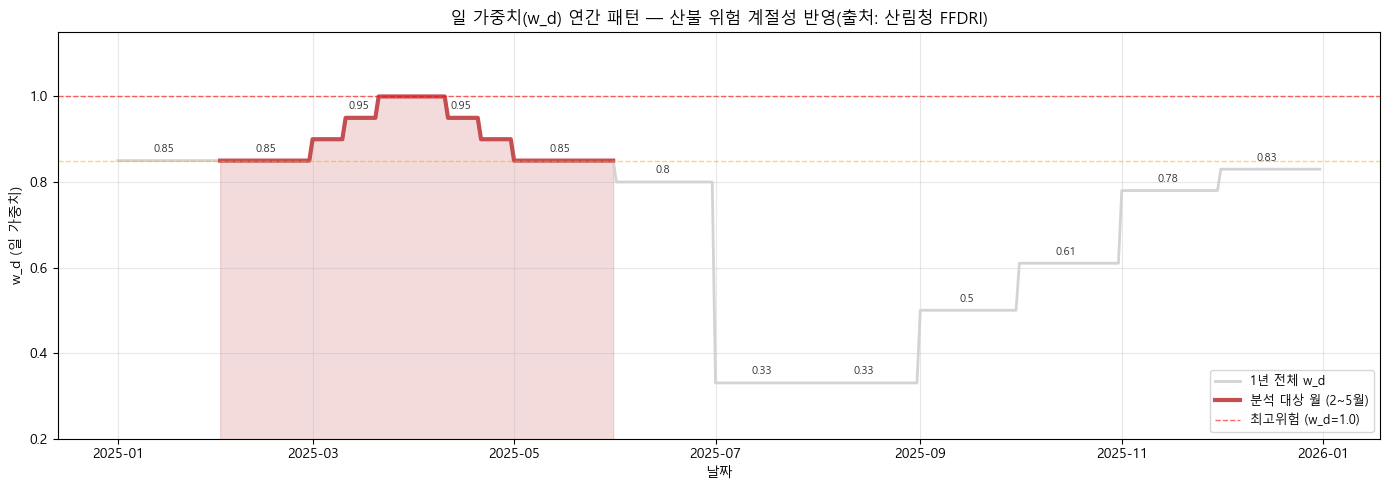

그래프 저장 완료: C:\SKN projects\weather\preprocessing\PREP04\PREP_04_일가중치패턴.png


In [35]:
# 1년 전체 패턴 (데이터 없는 구간도 포함)
all_months = pd.date_range('2025-01-01', '2025-12-31')
wd_year = pd.DataFrame({'date': all_months})
wd_year['w_d'] = wd_year['date'].apply(lambda d: get_wd(d.month, d.day))

# 데이터 보유 구간 표시: 2~5월
has_data = (wd_year['date'] >= '2025-02-01') & (wd_year['date'] <= '2025-05-31')

fig, ax = plt.subplots(figsize=(14, 5))

# 전체 라인
ax.plot(wd_year['date'], wd_year['w_d'],
        color='lightgray', linewidth=2, label='1년 전체 w_d')

# 데이터 보유 구간 강조
wd_data = wd_year[has_data]
ax.plot(wd_data['date'], wd_data['w_d'],
        color='#C44E52', linewidth=3, label='분석 대상 월 (2~5월)')
ax.fill_between(wd_data['date'], wd_data['w_d'], 0,
                alpha=0.2, color='#C44E52')

# 주요 기준선
ax.axhline(1.0, color='red', linewidth=1, linestyle='--', alpha=0.6, label='최고위험 (w_d=1.0)')
ax.axhline(0.85, color='orange', linewidth=1, linestyle='--', alpha=0.5)

# 구간 레이블
for m in range(1, 13):
    d = pd.Timestamp(f'2025-{m:02d}-15')
    wd = get_wd(m, 15)
    ax.text(d, wd + 0.02, f'{wd}', ha='center', fontsize=8, color='#333')

ax.set_xlabel('날짜')
ax.set_ylabel('w_d (일 가중치)')
ax.set_ylim(0.2, 1.15)
ax.set_title('일 가중치(w_d) 연간 패턴 — 산불 위험 계절성 반영(출처: 산림청 FFDRI)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_out = FIG_PATH / 'PREP_04_일가중치패턴.png'
plt.savefig(fig_out, dpi=120, bbox_inches='tight')
plt.show()

print(f'그래프 저장 완료: {fig_out}')

---
## Step 4. 시각화 — 2020~2025 분석기간 w_d 분포

6개년으로 확장되었으므로, 분석 기간 전체에서 w_d 값이 어떤 비율로 분포하는지 확인합니다.

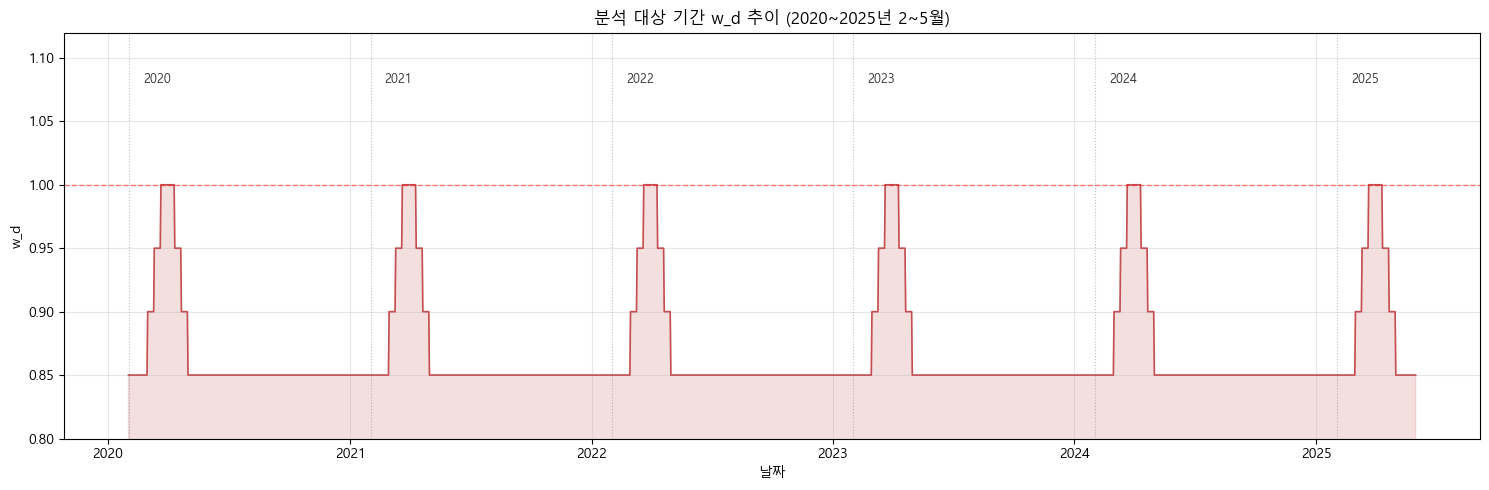

그래프 저장 완료: C:\SKN projects\weather\preprocessing\PREP04\PREP_04_일가중치_2020_2025_추이.png


In [36]:
# 6개년 전체 분석 기간 w_d 시계열
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(wd_df['date'], wd_df['w_d'], color='#C44E52', linewidth=1.2)
ax.fill_between(wd_df['date'], wd_df['w_d'], 0, alpha=0.18, color='#C44E52')

for y in YEARS:
    ax.axvline(pd.Timestamp(f'{y}-02-01'), color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(pd.Timestamp(f'{y}-03-15'), 1.08, str(y), ha='center', fontsize=9, color='#333')

ax.axhline(1.0, color='red', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('날짜')
ax.set_ylabel('w_d')
ax.set_ylim(0.8, 1.12)
ax.set_title('분석 대상 기간 w_d 추이 (2020~2025년 2~5월)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_out = FIG_PATH / 'PREP_04_일가중치_2020_2025_추이.png'
plt.savefig(fig_out, dpi=120, bbox_inches='tight')
plt.show()

print(f'그래프 저장 완료: {fig_out}')

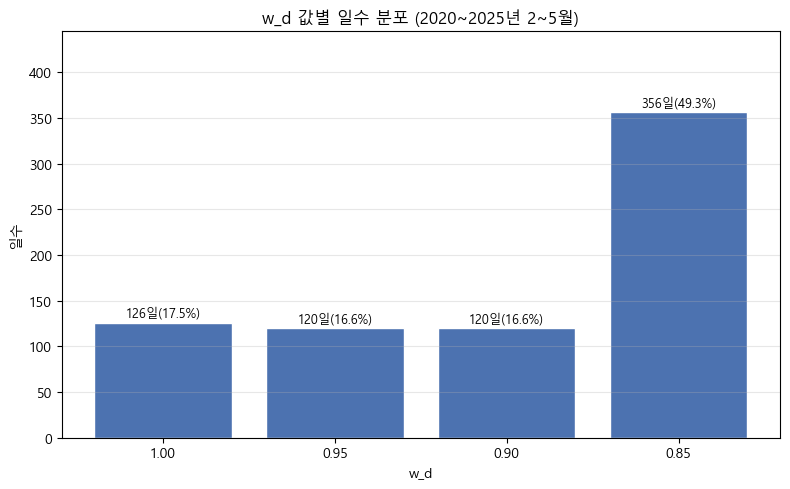

그래프 저장 완료: C:\SKN projects\weather\preprocessing\PREP04\PREP_04_일가중치_분포.png


In [37]:
# w_d 값별 일수 분포
vc = wd_df['w_d'].value_counts().sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'{v:.2f}' for v in vc.index], vc.values, color='#4C72B0', edgecolor='white')

for bar, cnt in zip(bars, vc.values):
    pct = cnt / len(wd_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{cnt}일({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('w_d')
ax.set_ylabel('일수')
ax.set_title('w_d 값별 일수 분포 (2020~2025년 2~5월)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, vc.max() * 1.25)

plt.tight_layout()
fig_out = FIG_PATH / 'PREP_04_일가중치_분포.png'
plt.savefig(fig_out, dpi=120, bbox_inches='tight')
plt.show()

print(f'그래프 저장 완료: {fig_out}')

---
## Step 5. DWI 계산에서의 활용 방법

> w_d는 날짜만 알면 되므로, 나중에 DWI 계산 시 날짜 기준으로 간단히 붙입니다.

In [38]:
print('=== DWI 계산에서 w_d 사용 예시 ===')
example_lines = [
    '# 날짜별 w_d 불러오기',
    'wd_df = pd.read_parquet("preprocessing/derived/w_d.parquet")',
    '',
    '# 날씨/기상위험 데이터에 w_d 붙이기',
    '# date 컬럼의 dtype이 양쪽 모두 datetime64[ns]인지 확인하는 것이 좋음',
    'df_dwi = df_weather.merge(wd_df[["date", "w_d"]], on="date", how="left")',
    '',
    '# DWI 공식 적용 예시',
    'df_dwi["DWI"] = df_dwi["PreDWI_class"] * df_dwi["rne"] * df_dwi["w_d"]',
]
print(''.join(example_lines))

print('=== 분석 기간(2020~2025년 2~5월) w_d 분포 ===')
vc = wd_df['w_d'].value_counts().sort_index(ascending=False)
for v, cnt in vc.items():
    pct = cnt / len(wd_df) * 100
    bar = '#' * int(round(pct / 2))
    print(f'  w_d={float(v):.2f}: {cnt:4d}일 ({pct:5.1f}%)  {bar}')

=== DWI 계산에서 w_d 사용 예시 ===
# 날짜별 w_d 불러오기wd_df = pd.read_parquet("preprocessing/derived/w_d.parquet")# 날씨/기상위험 데이터에 w_d 붙이기# date 컬럼의 dtype이 양쪽 모두 datetime64[ns]인지 확인하는 것이 좋음df_dwi = df_weather.merge(wd_df[["date", "w_d"]], on="date", how="left")# DWI 공식 적용 예시df_dwi["DWI"] = df_dwi["PreDWI_class"] * df_dwi["rne"] * df_dwi["w_d"]
=== 분석 기간(2020~2025년 2~5월) w_d 분포 ===
  w_d=1.00:  126일 ( 17.5%)  #########
  w_d=0.95:  120일 ( 16.6%)  ########
  w_d=0.90:  120일 ( 16.6%)  ########
  w_d=0.85:  356일 ( 49.3%)  #########################


---
## Step 6. 검증

날짜 누락, 중복, w_d 결측 여부를 확인합니다.

In [39]:
print('=== 검증: 저장된 w_d 데이터 ===')
check = pd.read_parquet(out_path)

print(f'행 수: {len(check):,}')
print(f'날짜 범위: {check["date"].min().date()} ~ {check["date"].max().date()}')
print(f'중복 날짜 수: {check.duplicated("date").sum():,}')
print(f'w_d 결측 수: {check["w_d"].isna().sum():,}')
print()

# 기대 날짜 수 계산
expected_dates = []
for y in YEARS:
    for m in TARGET_MONTHS:
        start = pd.Timestamp(f'{y}-{m:02d}-01')
        end = start + pd.offsets.MonthEnd(0)
        expected_dates.extend(pd.date_range(start, end))

expected_set = set(expected_dates)
actual_set = set(pd.to_datetime(check['date']))

missing_dates = sorted(expected_set - actual_set)
extra_dates = sorted(actual_set - expected_set)

print(f'기대 날짜 수: {len(expected_set):,}')
print(f'실제 날짜 수: {len(actual_set):,}')
print(f'누락 날짜 수: {len(missing_dates):,}')
print(f'초과 날짜 수: {len(extra_dates):,}')

if len(missing_dates) == 0 and len(extra_dates) == 0 and check['w_d'].isna().sum() == 0:
    print('=> w_d 날짜 테이블 정상')
else:
    print('=> 확인 필요')
    if missing_dates[:5]:
        print('누락 예시:', missing_dates[:5])
    if extra_dates[:5]:
        print('초과 예시:', extra_dates[:5])

=== 검증: 저장된 w_d 데이터 ===
행 수: 722
날짜 범위: 2020-02-01 ~ 2025-05-31
중복 날짜 수: 0
w_d 결측 수: 0

기대 날짜 수: 722
실제 날짜 수: 722
누락 날짜 수: 0
초과 날짜 수: 0
=> w_d 날짜 테이블 정상


---
## 최종 요약

In [40]:
print('=' * 60)
print('  파생변수 4: 일 가중치 w_d 생성 완료 (6개년 확장)')
print('=' * 60)
summary_lines = [
    '',
    '  출처: 산림청 FFDRI 알고리즘 설명서',
    '',
    '  처리 기간',
    '  - 2020~2025년 2~5월',
    f'  - 총 {len(wd_df):,}일',
    '  - 2020년은 윤년이므로 2월 29일 포함',
    '',
    '  값 범위 (분석 기간 2~5월)',
    '  - w_d = 1.00 : 3월 21일 ~ 4월 10일  (산불 최고 위험기)',
    '  - w_d = 0.95 : 3월 11~20일, 4월 11~20일',
    '  - w_d = 0.90 : 3월 1~10일, 4월 21~30일',
    '  - w_d = 0.85 : 2월 전체, 5월 전체',
    '',
    '  저장 위치',
    f'  - {out_path}',
    f'  - {compat_path}',
    '  - 컬럼: date, year, month, ym, w_d',
    '',
    '  DWI 공식에서의 역할',
    '  DWI = PreDWI_class * RNE * w_d',
    '  -> 같은 건조 조건이라도 3월 말이 5월보다 위험하게 평가됨',
]
print(''.join(summary_lines))

print('=' * 60)
print('  파생변수 생성 단계 요약')
print('=' * 60)
next_lines = [
    '',
    '  1. 실효습도 (EH)     preprocessing/derived/effective_humidity/  6개년 격자-날짜 단위',
    '  2. 강우효과 (RNE)    preprocessing/derived/rne/                 6개년 격자-날짜 단위',
    '  3. 일 가중치 (w_d)   preprocessing/derived/w_d.parquet          721행 날짜 단위',
    '',
    '  다음 단계: DWI(기상위험지수) 계산',
    '  -> EH + RNE + w_d + 기온 + 습도 + 풍속 조합',
]
print(''.join(next_lines))
print('=' * 60)

  파생변수 4: 일 가중치 w_d 생성 완료 (6개년 확장)
  출처: 산림청 FFDRI 알고리즘 설명서  처리 기간  - 2020~2025년 2~5월  - 총 722일  - 2020년은 윤년이므로 2월 29일 포함  값 범위 (분석 기간 2~5월)  - w_d = 1.00 : 3월 21일 ~ 4월 10일  (산불 최고 위험기)  - w_d = 0.95 : 3월 11~20일, 4월 11~20일  - w_d = 0.90 : 3월 1~10일, 4월 21~30일  - w_d = 0.85 : 2월 전체, 5월 전체  저장 위치  - C:\SKN projects\weather\preprocessing\derived\w_d_2020_2025.parquet  - C:\SKN projects\weather\preprocessing\derived\w_d.parquet  - 컬럼: date, year, month, ym, w_d  DWI 공식에서의 역할  DWI = PreDWI_class * RNE * w_d  -> 같은 건조 조건이라도 3월 말이 5월보다 위험하게 평가됨
  파생변수 생성 단계 요약
  1. 실효습도 (EH)     preprocessing/derived/effective_humidity/  6개년 격자-날짜 단위  2. 강우효과 (RNE)    preprocessing/derived/rne/                 6개년 격자-날짜 단위  3. 일 가중치 (w_d)   preprocessing/derived/w_d.parquet          721행 날짜 단위  다음 단계: DWI(기상위험지수) 계산  -> EH + RNE + w_d + 기온 + 습도 + 풍속 조합
